In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
# import urllib.request

# Download the dataset
# url = "https://raw.githubusercontent.com/defcom17/NSL_KDD/master/KDDTrain+.txt"
# urllib.request.urlretrieve(url, "KDDTrain.txt")

# Column names for the dataset
columns = ['duration','protocol_type','service','flag','src_bytes','dst_bytes',
           'land','wrong_fragment','urgent','hot','num_failed_logins','logged_in',
           'num_compromised','root_shell','su_attempted','num_root','num_file_creations',
           'num_shells','num_access_files','num_outbound_cmds','is_host_login',
           'is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
           'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate',
           'srv_diff_host_rate','dst_host_count','dst_host_srv_count',
           'dst_host_same_srv_rate','dst_host_diff_srv_rate','dst_host_same_src_port_rate',
           'dst_host_srv_diff_host_rate','dst_host_serror_rate','dst_host_srv_serror_rate',
           'dst_host_rerror_rate','dst_host_srv_rerror_rate','label','difficulty']

# Load into pandas
df = pd.read_csv(r"C:\Users\prisc\Downloads\KDD Dataset.txt", names=columns)
print("Dataset loaded successfully!")
print("Shape:", df.shape)
print(df.head())

Dataset loaded successfully!
Shape: (125973, 43)
   duration protocol_type   service flag  src_bytes  dst_bytes  land  \
0         0           tcp  ftp_data   SF        491          0     0   
1         0           udp     other   SF        146          0     0   
2         0           tcp   private   S0          0          0     0   
3         0           tcp      http   SF        232       8153     0   
4         0           tcp      http   SF        199        420     0   

   wrong_fragment  urgent  hot  ...  dst_host_same_srv_rate  \
0               0       0    0  ...                    0.17   
1               0       0    0  ...                    0.00   
2               0       0    0  ...                    0.10   
3               0       0    0  ...                    1.00   
4               0       0    0  ...                    1.00   

   dst_host_diff_srv_rate  dst_host_same_src_port_rate  \
0                    0.03                         0.17   
1                    0.

In [3]:
# Preprocess the data
# Simplify labels to binary: normal vs attack
df['label'] = df['label'].apply(lambda x: 'normal' if x == 'normal' else 'attack')

# Encode categorical columns
le = LabelEncoder()
df['protocol_type'] = le.fit_transform(df['protocol_type'])
df['service'] = le.fit_transform(df['service'])
df['flag'] = le.fit_transform(df['flag'])
df['label'] = le.fit_transform(df['label'])

# Drop difficulty column
df = df.drop('difficulty', axis=1)

# Split features and target
X = df.drop('label', axis=1)
y = df['label']

# Split into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data preprocessed successfully!")
print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Data preprocessed successfully!
Training samples: 100778
Testing samples: 25195


In [4]:
# Train all three ML models
# Model 1: Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_accuracy * 100, 2), "%")


Random Forest Accuracy: 99.87 %


In [5]:
print("Classes:", rf_model.classes_)

Classes: [0 1]


In [6]:
# Model 2: Decision Tree
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_accuracy = accuracy_score(y_test, dt_pred)
print("Decision Tree Accuracy:", round(dt_accuracy * 100, 2), "%")

Decision Tree Accuracy: 99.79 %


In [7]:
# Model 3: K-Nearest Neighbours
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)
knn_pred = knn_model.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_pred)
print("K-Nearest Neighbours Accuracy:", round(knn_accuracy * 100, 2), "%")

K-Nearest Neighbours Accuracy: 99.55 %


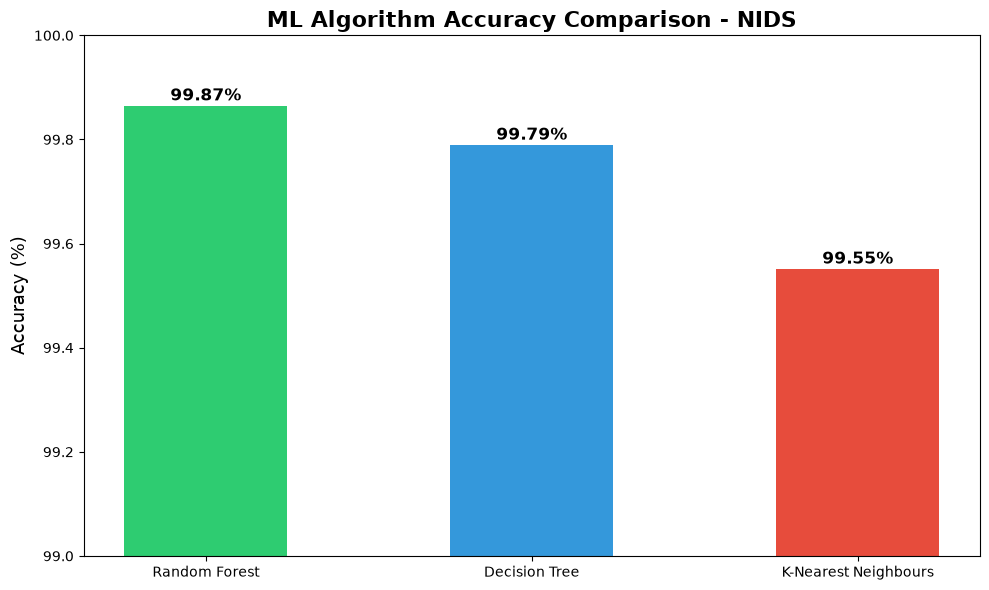

Chart saved!


In [8]:
# Visualise model comparison
models = ['Random Forest', 'Decision Tree', 'K-Nearest Neighbours']
accuracies = [rf_accuracy * 100, dt_accuracy * 100, knn_accuracy * 100]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#2ecc71', '#3498db', '#e74c3c'], width=0.5)
plt.title('ML Algorithm Accuracy Comparison - NIDS', fontsize=16, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=13)
plt.ylim([99, 100])

for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{acc:.2f}%', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()
print("Chart saved!")

BEST MODEL: RANDOM FOREST - DETAILED REPORT
              precision    recall  f1-score   support

      Attack       1.00      1.00      1.00     11773
      Normal       1.00      1.00      1.00     13422

    accuracy                           1.00     25195
   macro avg       1.00      1.00      1.00     25195
weighted avg       1.00      1.00      1.00     25195



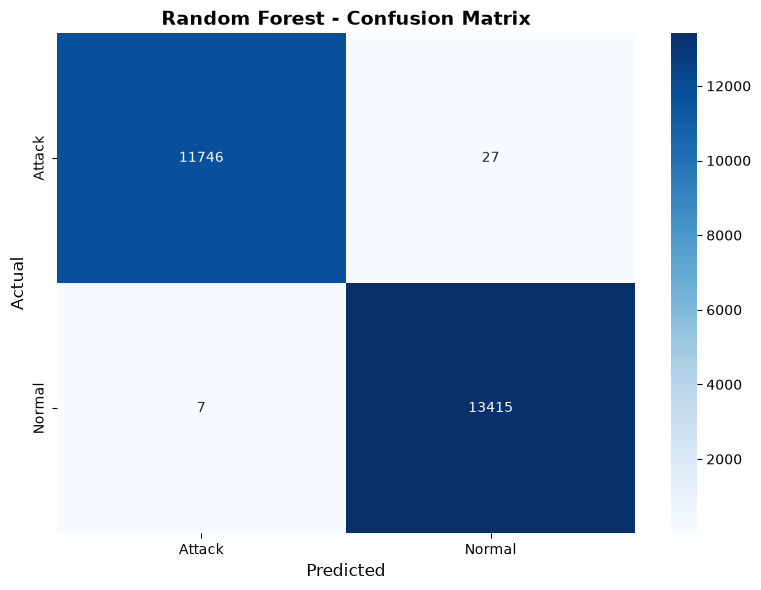

Confusion matrix saved!


In [9]:
# Detailed evaluation of best model (Random Forest)
print("=" * 50)
print("BEST MODEL: RANDOM FOREST - DETAILED REPORT")
print("=" * 50)
print(classification_report(y_test, rf_pred, 
      target_names=['Attack', 'Normal']))

# Confusion Matrix
cm = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Attack', 'Normal'],
            yticklabels=['Attack', 'Normal'])
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("Confusion matrix saved!")

In [10]:
# Summary
print("=" * 50)
print("   NIDS PROJECT - FINAL SUMMARY")
print("=" * 50)
print(f"Dataset: NSL-KDD (125,973 samples)")
print(f"Features: 41 network traffic features")
print(f"")
print(f"MODEL PERFORMANCE:")
print(f"Random Forest    : {rf_accuracy*100:.2f}%")
print(f"Decision Tree    : {dt_accuracy*100:.2f}%")
print(f"K-Nearest Neighbours: {knn_accuracy*100:.2f}%")
print(f"")
print(f"Best Model: Random Forest")
print(f"Conclusion: ML can detect network intrusions")
print(f"with near-perfect accuracy!")
print("=" * 50)

   NIDS PROJECT - FINAL SUMMARY
Dataset: NSL-KDD (125,973 samples)
Features: 41 network traffic features

MODEL PERFORMANCE:
Random Forest    : 99.87%
Decision Tree    : 99.79%
K-Nearest Neighbours: 99.55%

Best Model: Random Forest
Conclusion: ML can detect network intrusions
with near-perfect accuracy!


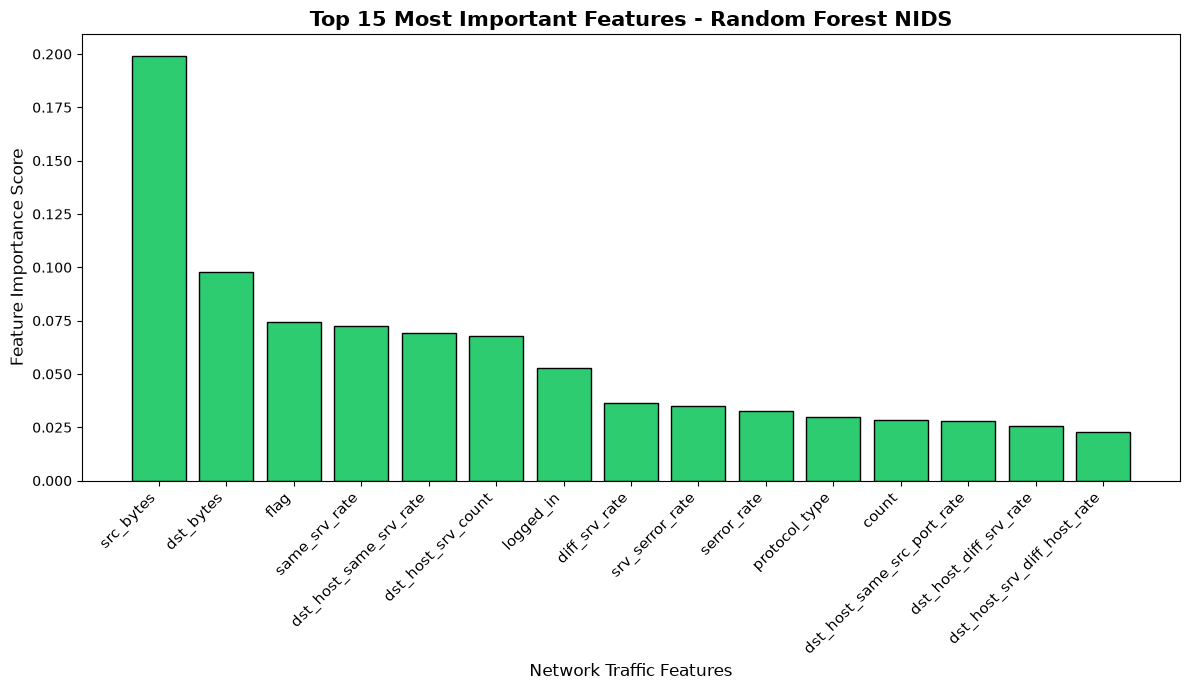

Feature importance chart saved!


In [11]:
# Feature Importance Chart
feature_names = X.columns.tolist()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # Top 15 features

plt.figure(figsize=(12, 7))
plt.title('Top 15 Most Important Features - Random Forest NIDS', 
          fontsize=15, fontweight='bold')
plt.bar(range(15), importances[indices], color='#2ecc71', edgecolor='black')
plt.xticks(range(15), [feature_names[i] for i in indices], 
           rotation=45, ha='right', fontsize=11)
plt.ylabel('Feature Importance Score', fontsize=12)
plt.xlabel('Network Traffic Features', fontsize=12)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("Feature importance chart saved!")

In [12]:
# Save the trained model for Flask
import joblib
joblib.dump(rf_model, 'nids_model.pkl')
print("Model saved successfully!")

Model saved successfully!
